# Lab assignment №1, part 3

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the third part of the assignment. First and second parts are waiting for you in the same directory.*__

##  Part 3. SVM and kernels

Kernels concept get adopted in variety of ML algorithms (e.g. Kernel PCA, Gaussian Processes, kNN, ...).

So in this task you are to examine kernels for SVM algorithm applied to rather simple artificial datasets.

To make it clear: we will work with the classification problem through the whole notebook.

In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

Let's generate our dataset and take a look on it.

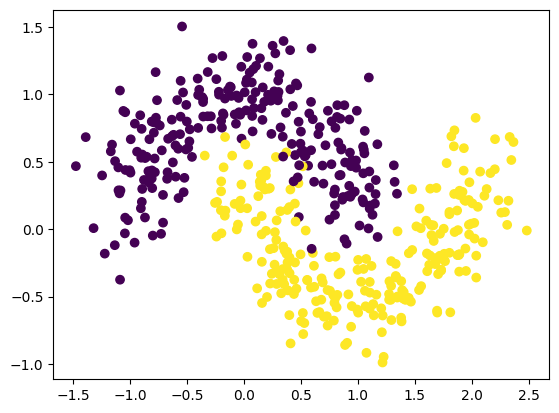

In [2]:
moons_points, moons_labels = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(moons_points[:, 0], moons_points[:, 1], c=moons_labels)

## 1.1 Pure models.
First let's try to solve this case with good old Logistic Regression and simple (linear kernel) SVM classifier.

Train LR and SVM classifiers (choose params by hand, no CV or intensive grid search neeeded) and plot their decision regions. Calculate one preffered classification metric.

Describe results in one-two sentences.

_Tip:_ to plot classifiers decisions you colud use either sklearn examples ([this](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html#sphx-glr-auto-examples-neural-networks-plot-mlp-alpha-py) or any other) and mess with matplotlib yourself or great [mlxtend](https://github.com/rasbt/mlxtend) package (see their examples for details)

_Pro Tip:_ wirte function `plot_decisions` taking a dataset and an estimator and plotting the results cause you want to use it several times below

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from mlxtend.plotting import plot_decision_regions

lr = LogisticRegression(C=1, solver='liblinear', penalty='l1', random_state=42) # add some params
svm = SVC(kernel='linear', C=10, random_state=42) # here too

### YOUR CODE HERE

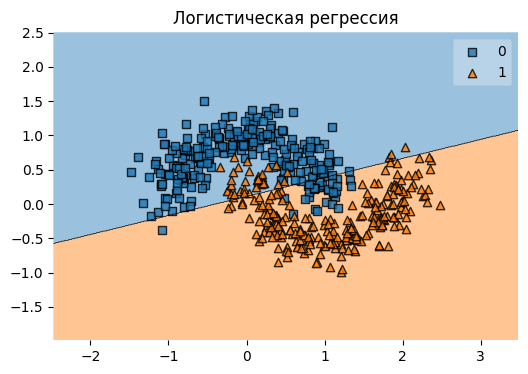

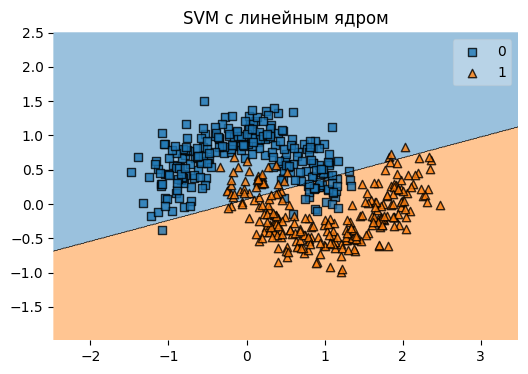

Accuracy логистической регрессии: 0.86
SVM Accuracy: 0.862


In [4]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

def plot_decisions(X, y, model, title):
    plt.figure(figsize=(6, 4))
    plot_decision_regions(X, y, clf=model)
    plt.title(title)
    plt.show()

#log_reg = LogisticRegression(C=1, solver='liblinear', penalty='l1', random_state=42)
lr.fit(moons_points, moons_labels)

#svm = SVC(kernel='linear', C=10, random_state=42)
svm.fit(moons_points, moons_labels)

plot_decisions(moons_points, moons_labels, lr, 'Логистическая регрессия')
plot_decisions(moons_points, moons_labels, svm, 'SVM с линейным ядром')

lr_acc = accuracy_score(moons_labels, lr.predict(moons_points))
svm_acc = accuracy_score(moons_labels, svm.predict(moons_points))

print('Accuracy логистической регрессии:', lr_acc)
print('SVM Accuracy:', svm_acc)


Применение логистической регрессии и метода опорных векторов с линейным ядром показывают похожие результаты. Ручное изменение гиперпараметров модели несколько изменяют accuracy.

## 1.2 Kernel tirck

Now use different kernels (`poly`, `rbf`, `sigmoid`) on SVC to get better results. Play `degree` parameter and others.

For each kernel estimate optimal params, plot decision regions, calculate metric you've chosen eariler.

Write couple of sentences on:

* What have happenned with classification quality?
* How did decision border changed for each kernel?
* What `degree` have you chosen and why?

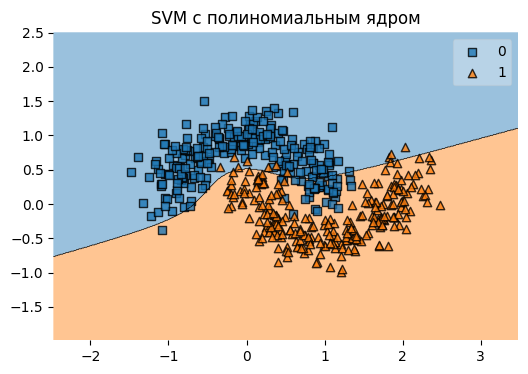

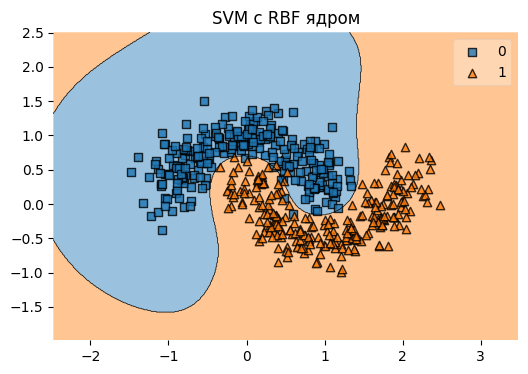

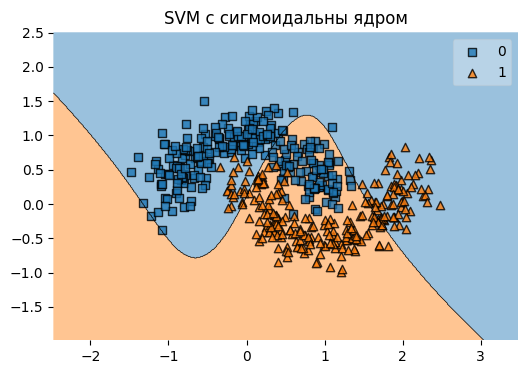

SVM с полиномиальным ядром Accuracy: 0.906
SVM с RBF ядром Accuracy: 0.982
SVM с сигмоидальным ядром: 0.644


In [5]:
### YOUR CODE HERE

svm_poly = SVC(kernel='poly', degree=3, C=1, random_state=42)
svm_poly.fit(moons_points, moons_labels)

svm_rbf = SVC(kernel='rbf', gamma='scale', C=100, random_state=42)
svm_rbf.fit(moons_points, moons_labels)

svm_sig = SVC(kernel='sigmoid', gamma='scale', C=5, random_state=42)
svm_sig.fit(moons_points, moons_labels)

plot_decisions(moons_points, moons_labels, svm_poly, 'SVM с полиномиальным ядром')
plot_decisions(moons_points, moons_labels, svm_rbf, 'SVM с RBF ядром')
plot_decisions(moons_points, moons_labels, svm_sig, 'SVM с сигмоидальны ядром')

svm_poly_acc = accuracy_score(moons_labels, svm_poly.predict(moons_points))
svm_rbf_acc = accuracy_score(moons_labels, svm_rbf.predict(moons_points))
svm_sig_acc = accuracy_score(moons_labels, svm_sig.predict(moons_points))

print('SVM с полиномиальным ядром Accuracy:', svm_poly_acc)
print('SVM с RBF ядром Accuracy:', svm_rbf_acc)
print('SVM с сигмоидальным ядром:', svm_sig_acc)


1. Качество классификации изменилось. Полиномиальное ядро показало лучше результаты при степени равной 3. RBF ядро также улучшило показатель accuracy, наилучший результат получен при c=5 и более. Сигмоидальное ядро привело к худшим результатам.

2. Граница решений изменилась. Полиномиальное ядро создает более криволинейные границы и это зависит от выбранной степени. Границы, созданные RBF ядром, также носят криволинейный характер и хорошо обрисовывают форму самих данных.Сигмоидальное ядро создало также нелинейные границы, но они оказались менее четкими для разделения классов в данном примере.

3. Для полиномиального ядра я выбрала степень 3, так как она привела к наилучшему показателю accuracy.

## 1.3 Simpler solution (of a kind)
What is we could use Logisitc Regression to successfully solve this task?

Feature generation is a thing to help here. Different techniques of feature generation are used in real life, couple of them will be covered in additional lectures.

In particular case simple `PolynomialFeatures` ([link](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)) are able to save the day.

Generate the set of new features, train LR on it, plot decision regions, calculate metric.

* Comare SVM's results with this solution (quality, borders type)
* What degree of PolynomialFeatures have you used? Compare with same SVM kernel parameter.

In [6]:
from sklearn.preprocessing import PolynomialFeatures

### YOUR CODE HERE

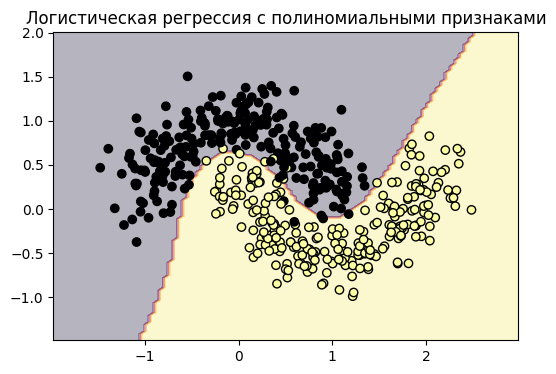

Логистическая регрессия с полиномиальными признаками Accuracy: 0.978


In [7]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(moons_points)

lr_poly = LogisticRegression(C=10, solver='liblinear', random_state=42)
lr_poly.fit(X_poly, moons_labels)

x_min, x_max = moons_points[:, 0].min() - 0.5, moons_points[:, 0].max() + 0.5
y_min, y_max = moons_points[:, 1].min() - 0.5, moons_points[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

grid_points = poly.transform(np.c_[xx.ravel(), yy.ravel()])
Z = lr_poly.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='inferno')
plt.scatter(moons_points[:, 0], moons_points[:, 1], c=moons_labels, edgecolors='k', marker='o', cmap='inferno')
plt.title('Логистическая регрессия с полиномиальными признаками')
plt.show()

lr_poly_acc = accuracy_score(moons_labels, lr_poly.predict(X_poly))

print('Логистическая регрессия с полиномиальными признаками Accuracy:', lr_poly_acc)


Результаты классификации, показанные логистической регрессией с полиномиальными признаками, по качеству сопоставимы с результатами SVM, в частности уступает SVM с RBF ядром и лучше, чем SVM с полиномиальным ядром с такой же степенью.
Логистическая регрессия с полиномиальными признаками создала сложную криволинейную границу, аналогичную SVM. Однако она оказалась менее гладкой.
В данном примере использовалась степень 3 для сопоставления с SVM с полиномиальным ядром. Однако использование степени 4 увеличивает показатель accuracy (0.978 degree=3 vs. 0.982 degree=4), но, возможно, это будет способствовать переобучению модели.


## 1.4 Harder problem

Let's make this task a bit more challenging via upgrading dataset:

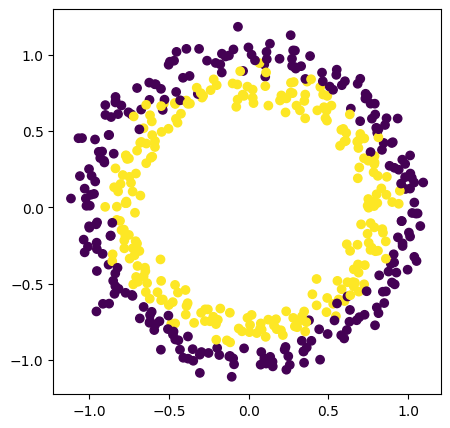

In [8]:
from sklearn.datasets import make_circles

circles_points, circles_labels = make_circles(n_samples=500, noise=0.06, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(circles_points[:, 0], circles_points[:, 1], c=circles_labels)

And even more:

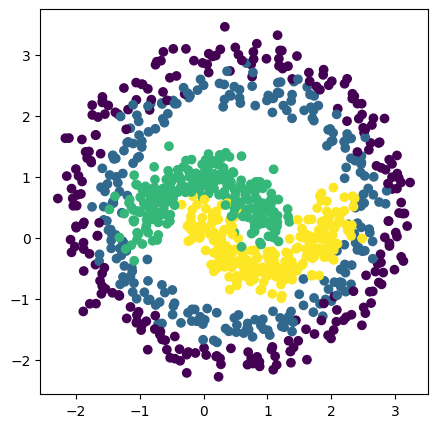

In [9]:
points = np.vstack((circles_points*2.5 + 0.5, moons_points))
labels = np.hstack((circles_labels, moons_labels + 2)) # + 2 to distinct moons classes

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], c=labels)

Now do your best using all the approaches above!

Tune LR with generated features, SVM with appropriate kernel of your choice. You may add some of your loved models to demonstrate their (and your) strength. Again plot decision regions, calculate metric.

Justify the results in a few phrases.

In [ ]:
### YOUR CODE HERE

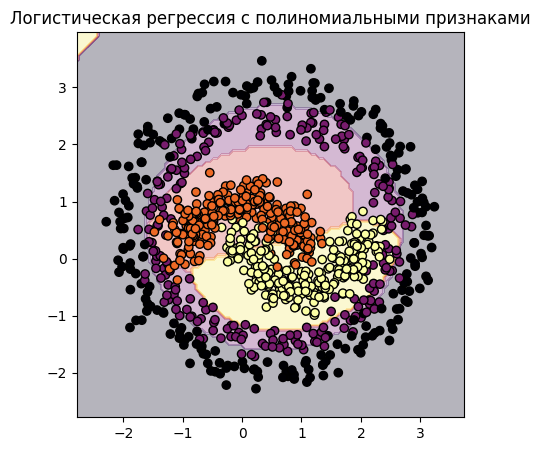

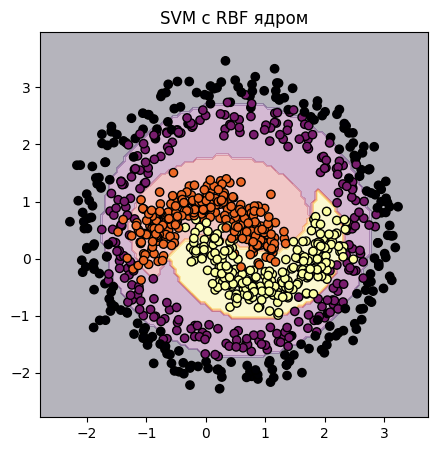

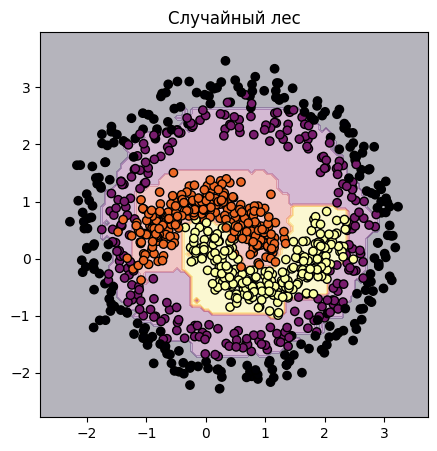

Логистическая регрессия с полиномиальными признаками Accuracy: 0.839
SVM с RBF ядром Accuracy: 0.921
Случайный лес Accuracy: 1.0


In [10]:
from sklearn.ensemble import RandomForestClassifier

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(points)

lr_poly = LogisticRegression(C=1, solver='liblinear', random_state=42)
lr_poly.fit(X_poly, labels)

svm_rbf = SVC(kernel='rbf', gamma='scale', C=1, random_state=42)
svm_rbf.fit(points, labels)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(points, labels)

# Универсальная функция для визуализации решений
def plot_decision_universal(X, y, model, title, poly_features=None):
    plt.figure(figsize=(5, 5))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    if poly_features is not None:
        grid_points = poly_features.transform(grid_points)

    # Предсказания и визуализация
    Z = model.predict(grid_points).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='inferno')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap='inferno')
    plt.title(title)
    plt.show()

plot_decision_universal(points, labels, lr_poly, 'Логистическая регрессия с полиномиальными признаками', poly_features=poly)
plot_decision_universal(points, labels, svm_rbf, 'SVM с RBF ядром')
plot_decision_universal(points, labels, rf, 'Случайный лес')

lr_poly_acc = accuracy_score(labels, lr_poly.predict(X_poly))
svm_rbf_acc = accuracy_score(labels, svm_rbf.predict(points))
rf_acc = accuracy_score(labels, rf.predict(points))

print('Логистическая регрессия с полиномиальными признаками Accuracy:', lr_poly_acc)
print('SVM с RBF ядром Accuracy:', svm_rbf_acc)
print('Случайный лес Accuracy:', rf_acc)


Логистическая регрессия с полиномиальными признаками улучшает разделение классов по сравнению с обычной логистической регрессией, однако не является наилучшим решением в наборах данных высокой сложности.
SVM с RBF ядром показывает лучше результаты и создает более точные границы разделения классов. Случайный лес также хорош на таких данных.
Таким образом, можно сделать вывод, что более сложные модели, такие как SVM с RBF и случайные леса, демонстрируют большую точность на нелинейных задачах.